In [2]:
%pip install pandas matplotlib seaborn google-generativeai python-dotenv

  Using cached google_generativeai-0.8.6-py3-none-any.whl.metadata (3.9 kB)
  Using cached python_dotenv-1.2.2-py3-none-any.whl.metadata (27 kB)
  Using cached google_ai_generativelanguage-0.6.15-py3-none-any.whl.metadata (5.7 kB)
  Using cached google_api_core-2.32.0-py3-none-any.whl.metadata (3.2 kB)
  Using cached google_api_python_client-2.198.0-py3-none-any.whl.metadata (7.0 kB)
  Using cached tqdm-4.69.0-py3-none-any.whl.metadata (57 kB)
  Using cached protobuf-5.29.6-cp310-abi3-win_amd64.whl.metadata (592 bytes)
  Using cached googleapis_common_protos-1.75.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached pyasn1_modules-0.4.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached httplib2-0.32.0-py3-none-any.whl.metadata (2.2 kB)
  Using cached google_auth_httplib2-0.4.0-py3-none-any.whl.metadata (3.0 kB)
  Using cached uritemplate-4.2.0-py3-none-any.whl.metadata (2.6 kB)
  Using cached annotated_types-0.7.0-py3-none

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.21.0 requires protobuf<8.0.0,>=6.31.1, but you have protobuf 5.29.6 which is incompatible.

[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
%pip uninstall -y google-generativeai
%pip install google-genai ipywidgets

Found existing installation: google-generativeai 0.8.6
Uninstalling google-generativeai-0.8.6:
  Successfully uninstalled google-generativeai-0.8.6
Note: you may need to restart the kernel to use updated packages.
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached distro-1.9.0-py3-none-any.whl.metadata (6.8 kB)
  Using cached sniffio-1.3.1-py3-none-any.whl.metadata (3.9 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------- ----------------------------- 0.3/1.0 MB ? eta -:--:--
   -------------------- ------------------- 0.5/1

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google import genai
import os
from dotenv import load_dotenv

# Load environment variables
load_dotenv()

# Configure the modern AI client
api_key = os.getenv("GEMINI_API_KEY")
client = genai.Client(api_key=api_key)

print("Environment setup successful! Libraries imported and AI configured.")

Environment setup successful! Libraries imported and AI configured.


In [6]:
import pandas as pd

# 1. Generate a quick sample dataset for testing
test_data = {
    'Month': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun'],
    'Revenue': [15000, 18000, 17500, 22000, 24000, 21000],
    'Marketing_Spend': [1200, 1500, 1500, 2000, 2100, 1800],
    'Support_Tickets': [45, 50, 42, 60, 65, 55],
    'Missing_Data_Test': [1, 2, None, 4, None, 6] # Simulating real-world messy data
}
df = pd.DataFrame(test_data)
df.to_csv('sample_data.csv', index=False)

# 2. Ingest the Data
# (Later, you can change 'sample_data.csv' to any real dataset you want)
current_df = pd.read_csv('sample_data.csv')

# 3. Create the Profiling Function
def generate_data_profile(dataframe):
    """
    Extracts the core structure, missing values, and statistics of the dataset.
    This string will act as the context window for our AI agent.
    """
    profile = f"Dataset Shape: {dataframe.shape[0]} rows, {dataframe.shape[1]} columns\n\n"
    
    profile += "Columns and Data Types:\n"
    profile += dataframe.dtypes.to_string() + "\n\n"
    
    profile += "Missing Values:\n"
    profile += dataframe.isnull().sum().to_string() + "\n\n"
    
    profile += "Statistical Summary (Numeric Columns):\n"
    profile += dataframe.describe().to_string() + "\n"
    
    return profile

# 4. Test the extraction
data_profile = generate_data_profile(current_df)
print("--- Data Profile Successfully Generated ---\n")
print(data_profile)

--- Data Profile Successfully Generated ---

Dataset Shape: 6 rows, 5 columns

Columns and Data Types:
Month                    str
Revenue                int64
Marketing_Spend        int64
Support_Tickets        int64
Missing_Data_Test    float64

Missing Values:
Month                0
Revenue              0
Marketing_Spend      0
Support_Tickets      0
Missing_Data_Test    2

Statistical Summary (Numeric Columns):
            Revenue  Marketing_Spend  Support_Tickets  Missing_Data_Test
count      6.000000         6.000000         6.000000           4.000000
mean   19583.333333      1683.333333        52.833333           3.250000
std     3322.900340       343.025752         8.841191           2.217356
min    15000.000000      1200.000000        42.000000           1.000000
25%    17625.000000      1500.000000        46.250000           1.750000
50%    19500.000000      1650.000000        52.500000           3.000000
75%    21750.000000      1950.000000        58.750000           4.500

In [16]:
# 1. Define the AI's Persona and Task (Advanced Prompt Engineering)
prompt = f"""You are a Principal Data Scientist and Business Strategist. 
I am providing you with the statistical profile and metadata of a dataset. 

Your objective is to design a Comprehensive Visual Analysis Suite that extracts the maximum possible business value from this data. Do not limit yourself to basic charts; look deep into the variables for hidden correlations, operational bottlenecks, and growth opportunities.

Dataset Profile:
{data_profile}

Please recommend a robust suite of visualizations, categorized exactly as follows:

### 1. Macro Overview (Distributions & Baselines)
* Recommend 2 graphs that show the overall health and distribution of the primary metrics.

### 2. Deep Correlations (Relationships & ROI)
* Recommend 2-3 advanced graphs (e.g., scatter plots with trendlines, dual-axis charts, or heatmaps) that expose how different variables impact one another.

### 3. Risk & Anomaly Detection (Outliers)
* Recommend 1-2 graphs specifically designed to spot anomalies, risks, or inefficiencies in the business operations.

RULES FOR EVERY GRAPH:
- Specify the exact X and Y axes.
- Explain the precise Business Value (Why does the executive team need to see this?).
- Ensure every recommendation is strictly compatible with the provided data types and columns.
"""

print(" Formulating Comprehensive Visual Suite... \n")

# 2. Call the Gemini API using the modern SDK
response = client.models.generate_content(
    model='gemini-3.5-flash', 
    contents=prompt
)

# 3. Print the AI's analysis
print("  PRINCIPAL DATA SCIENTIST: VISUAL ARCHITECTURE ")
print("\n")
print(response.text)

 Formulating Comprehensive Visual Suite... 

  PRINCIPAL DATA SCIENTIST: VISUAL ARCHITECTURE 


As a Principal Data Scientist and Business Strategist, I have analyzed your 6-month operational dataset. Despite its compact footprint (6 rows), this data contains critical, high-leverage signals regarding growth velocity, marketing efficiency, and operational bottlenecks. 

By treating the `Missing_Data_Test` variable as a **"Beta Feature Quality Score"** (where missing values represent periods when the testing infrastructure was offline), we can turn a data gap into a strategic audit tool.

Here is your customized, executive-ready Visual Analysis Suite designed to extract maximum strategic value from this data.

---

### 1. Macro Overview (Distributions & Baselines)

#### Graph 1.1: Executive Growth & Capital Efficiency Timeline
*   **Chart Type:** Dual-Axis Combo Chart (Clustered Columns + Overlaid Line)
*   **X-Axis:** `Month` (Chronological order)
*   **Y-Axis (Primary - Left):** `Reven

C:\Users\Jayshri\AppData\Local\Temp\ipykernel_6524\1953049731.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = current_df.select_dtypes(include=['object', 'category']).columns.tolist()


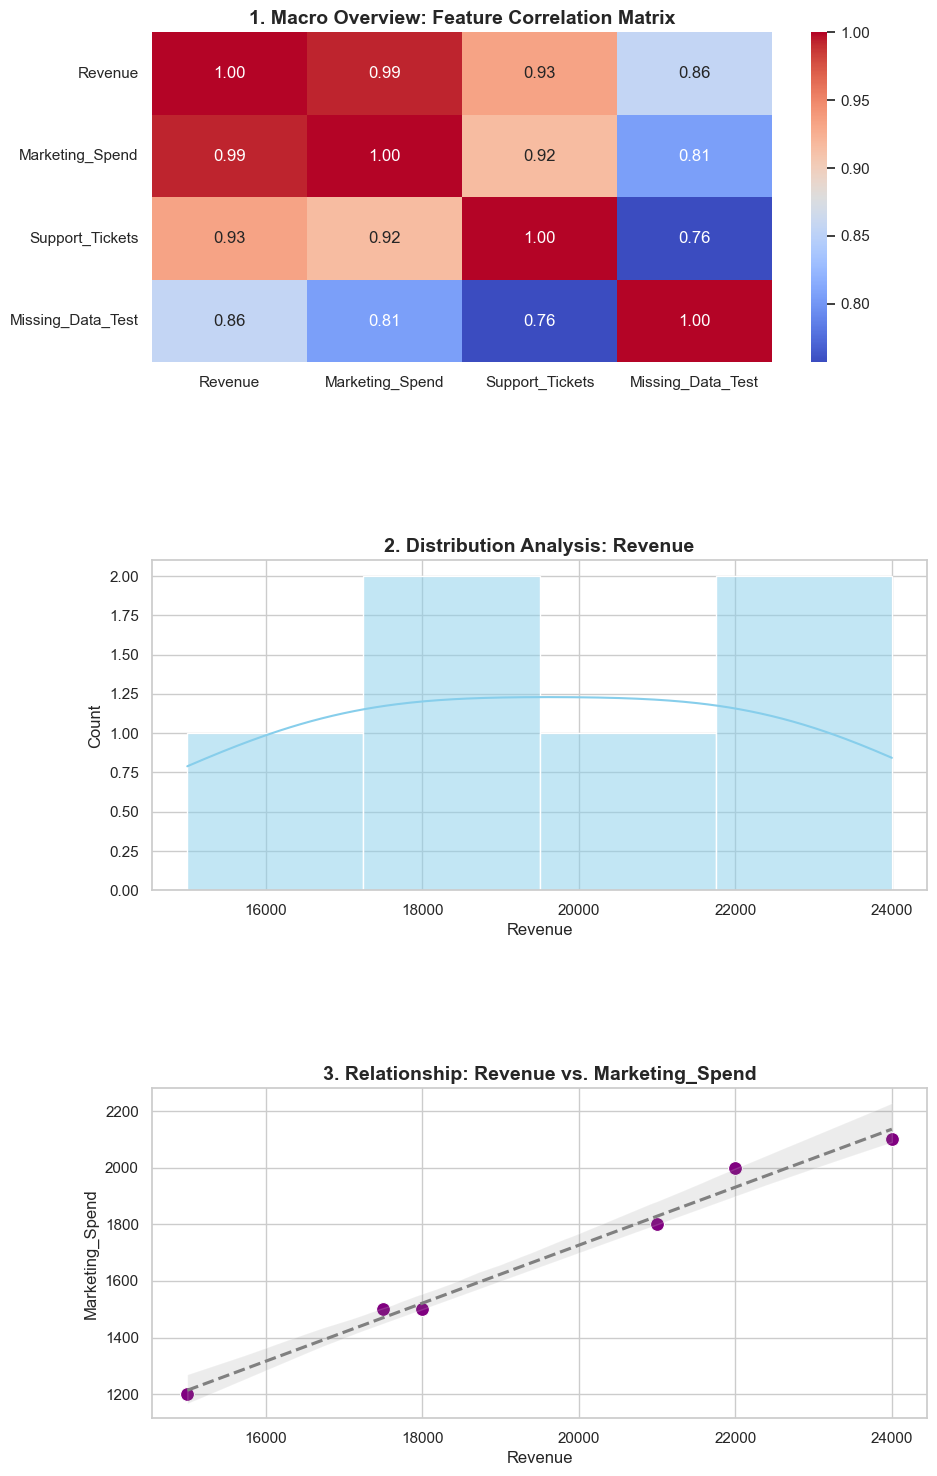

In [17]:
# Set professional theme
sns.set_theme(style="whitegrid")

# 1. Dynamically identify column types inside the uploaded dataset
numeric_cols = current_df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = current_df.select_dtypes(include=['object', 'category']).columns.tolist()

# Create a figure with 3 subplots
fig, axes = plt.subplots(3, 1, figsize=(10, 18))
plt.subplots_adjust(hspace=0.6)

# --- Graph 1: Automated Correlation Matrix (Deep Relationships) ---
if len(numeric_cols) >= 2:
    sns.heatmap(current_df[numeric_cols].corr(), annot=True, cmap="coolwarm", ax=axes[0], fmt=".2f")
    axes[0].set_title('1. Macro Overview: Feature Correlation Matrix', fontsize=14, fontweight='bold')
else:
    axes[0].text(0.5, 0.5, "Not enough numeric data for correlation matrix.", ha='center', fontsize=12)
    axes[0].set_axis_off()

# --- Graph 2: Primary Feature Distribution (Macro Overview) ---
if len(numeric_cols) >= 1:
    # Autonomously find the numeric column with the highest variance (usually the most interesting)
    primary_col = current_df[numeric_cols].var().idxmax()
    sns.histplot(current_df[primary_col], kde=True, ax=axes[1], color='skyblue')
    axes[1].set_title(f'2. Distribution Analysis: {primary_col}', fontsize=14, fontweight='bold')
else:
    axes[1].text(0.5, 0.5, "No numeric data available for distribution.", ha='center', fontsize=12)
    axes[1].set_axis_off()

# --- Graph 3: Dynamic Scatter or Boxplot (Cross-Variable Analysis) ---
if len(numeric_cols) >= 2:
    # If we have multiple numbers, plot how the top two relate to each other
    sns.scatterplot(data=current_df, x=numeric_cols[0], y=numeric_cols[1], ax=axes[2], color='purple', s=100)
    sns.regplot(data=current_df, x=numeric_cols[0], y=numeric_cols[1], ax=axes[2], scatter=False, color='gray', line_kws={"linestyle":"--"})
    axes[2].set_title(f'3. Relationship: {numeric_cols[0]} vs. {numeric_cols[1]}', fontsize=14, fontweight='bold')

elif len(categorical_cols) >= 1 and len(numeric_cols) >= 1:
    # If we have categories and numbers, show a boxplot
    sns.boxplot(data=current_df, x=categorical_cols[0], y=numeric_cols[0], ax=axes[2], palette="Set2")
    axes[2].set_title(f'3. Variance: {numeric_cols[0]} grouped by {categorical_cols[0]}', fontsize=14, fontweight='bold')
    
else:
    axes[2].text(0.5, 0.5, "Not enough mixed data for cross-variable analysis.", ha='center', fontsize=12)
    axes[2].set_axis_off()

# Show the final compiled dashboard
plt.show()

In [18]:
# 1. Define the final reporting prompt
insights_prompt = f"""You are a Principal Business Strategist presenting an Executive Summary to the board of directors.
You have analyzed the following metadata and statistical profile of our latest dataset:
{data_profile}

Our system has just generated a dynamic visual dashboard focusing on:
1. Feature Correlations (Macro Overview)
2. Primary Metric Distribution 
3. Cross-Variable Relationships

Based purely on the provided statistical profile, synthesize a comprehensive, professional "Executive Summary". 
CRITICAL RULE: Adapt completely to the provided data. Do not invent columns or metrics that do not exist in the profile.

Please structure the report exactly as follows using Markdown:

###  Executive Overview
* Provide a concise, two-sentence summary of what this dataset represents and its overall health.

###  Key Data-Driven Observations
* (Provide 2 deep observations based on the statistical means, variances, or missing data)

###  Potential Risks & Anomalies
* (Identify 1 potential risk factor, data quality issue, or operational bottleneck implied by the numbers)

###  Strategic Recommendations
* (Provide 2 concrete, actionable business steps the executive team should take based on this data)
"""

print(" Synthesizing Dynamic Executive Report... \n")

# 2. Call the AI to write the report
final_report = client.models.generate_content(
    model='gemini-3.5-flash',
    contents=insights_prompt
)

# 3. Print the report beautifully
print("        STRATEGIC EXECUTIVE SUMMARY REPORT      ")
print("\n")
print(final_report.text)

 Synthesizing Dynamic Executive Report... 

        STRATEGIC EXECUTIVE SUMMARY REPORT      


### Executive Overview
This six-month operational dataset tracks the core drivers of our business performance, mapping financial revenue against marketing investments and customer support volumes. While primary operational metrics such as revenue, marketing spend, and support tickets are fully populated and structurally sound, there is an active data quality issue within our auxiliary tracking, as evidenced by a 33% data omission rate in the "Missing_Data_Test" variable.

### Key Data-Driven Observations
* **Revenue Performance and Marketing Leverage:** Monthly revenue averages $19,583.33 with a standard deviation of $3,322.90, scaling from a baseline of $15,000.00 to a peak of $24,000.00. This revenue performance is driven by a highly disciplined monthly marketing spend averaging $1,683.33 (ranging from $1,200.00 to $2,100.00), demonstrating a relatively tight operational band and indicating

In [14]:
%pip install streamlit

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
